In [11]:
import os
import sys
import json
import pickle
import warnings
import numpy as np
import sympy as sp
import pandas as pd
import proplot as pplt
from IPython.display import display, HTML
sys.path.insert(0,'..')
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [12]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
MODELSDIR = CONFIGS['filepaths']['models']
SRCONFIG  = CONFIGS['experiments']['sr']
SEEDS     = SRCONFIG['seeds']

In [13]:
VARDICT = {
    'rh':       r'\widehat{\mathrm{RH}}',
    'thetae':   r'\widehat{\theta}_{e}',
    'thetaestar':r'{\widehat{\theta}_{e}^{*}}',
    'bl':       r'\mathrm{B_L}',
    'lf':       r'\mathrm{LF}',
    'shf':      r'\mathrm{SHF}',
    'lhf':      r'\mathrm{LHF}'}

SYMBOLS  = {k: sp.Symbol(k) for k in VARDICT}

FUNCDICT = {
    'cube':   lambda x: x**3,
    'square': lambda x: x**2,
    'sqrt':   sp.sqrt,
    'abs':    sp.Abs,
    'neg':    lambda x: -x,
    'exp':    sp.exp,
    'log':    sp.log,
    'sin':    sp.sin,
    'cos':    sp.cos,
    'max':    sp.Max,
    'min':    sp.Min}

TERMORDER = {'bl':0,'rh':1,'thetae':2,'thetaestar':3,'lf':4,'shf':5,'lhf':6}

def _to_sympy_expr(eq):
    return sp.sympify(eq, locals={**SYMBOLS, **FUNCDICT})

def _round_numbers(expr, ndigits=4):
    return expr.xreplace({n: sp.Float(round(float(n), ndigits), ndigits) for n in expr.atoms(sp.Float)})

def _term_key(term):
    symbols = term.free_symbols
    if not symbols:
        return (99, str(term))
    names = sorted(s.name for s in symbols)
    return (min(TERMORDER.get(n, 50) for n in names), str(term))

def _ordered_add_terms(expr):
    if isinstance(expr, sp.Add):
        terms = sp.Add.make_args(expr)
        return sp.Add(*sorted(terms, key=_term_key), evaluate=False)
    return expr

def _order_expr(expr):
    if expr.args:
        expr = expr.func(*[_order_expr(arg) for arg in expr.args], evaluate=False)
    if isinstance(expr, sp.Add):
        expr = _ordered_add_terms(expr)
    return expr

def _latex_expr(expr):
    symbolnames = {SYMBOLS[k]: v for k, v in VARDICT.items()}
    latex = sp.latex(expr, symbol_names=symbolnames, mul_symbol='dot')
    latex = latex.replace(r'\left', '').replace(r'\right', '')
    latex = ' '.join(latex.split())
    return latex

def prettify(eq):
    try:
        expr = _to_sympy_expr(str(eq).strip())
        expr = sp.expand(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$' + _latex_expr(expr) + '$'
    except Exception:
        return str(eq).strip()

def load_equations(runname):
    seedframes = {}
    for seed in SEEDS:
        filepath = os.path.join(MODELSDIR, 'sr', f'{runname}_{seed}_equations.csv')
        if not os.path.exists(filepath):
            continue
        df = pd.read_csv(filepath)
        df['seed'] = seed
        seedframes[seed] = df
    return seedframes

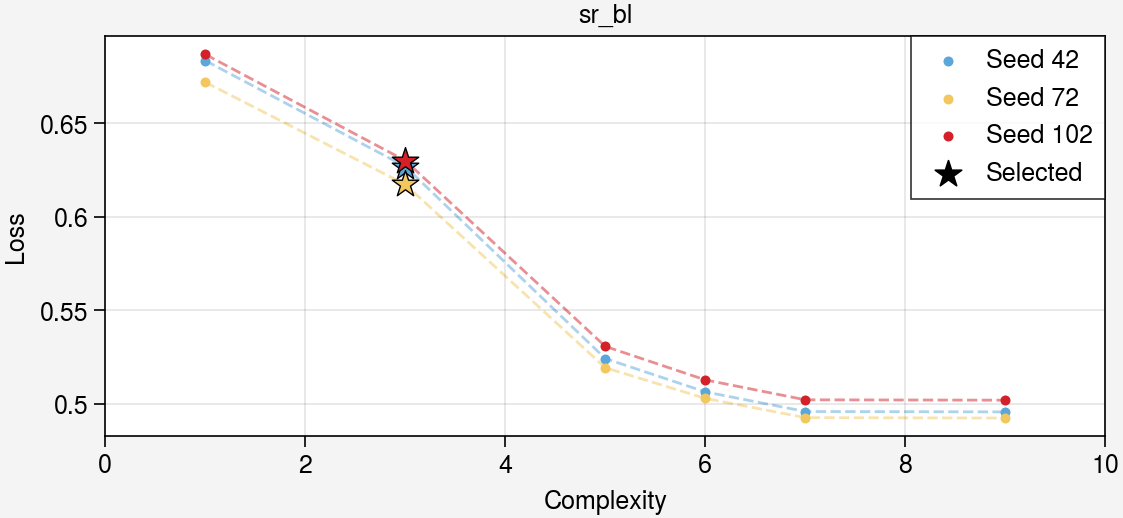

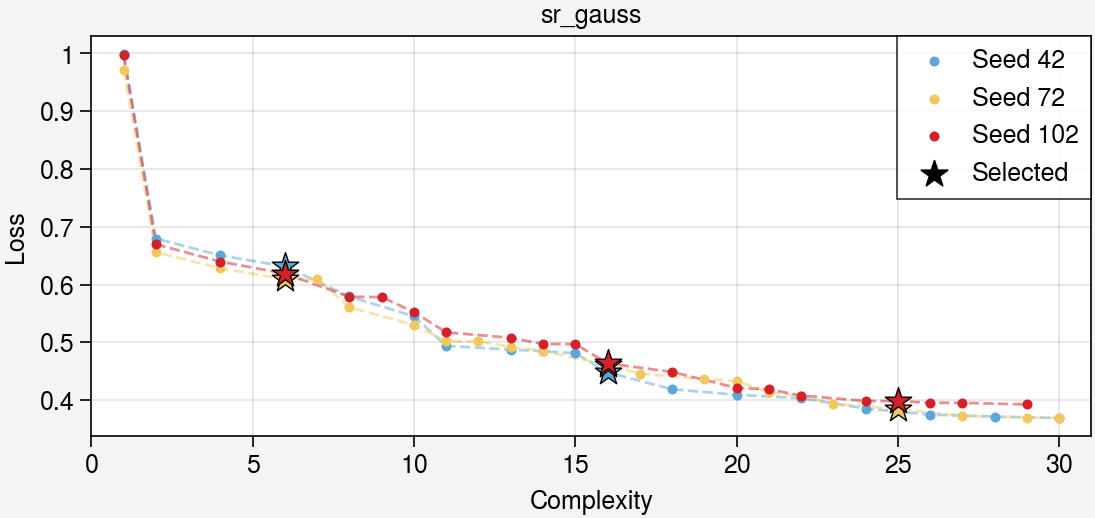

In [14]:
COLORS = ['#5BA7DA', '#F2C85E', '#D42028']

for runname in SRCONFIG['runs']:
    seedframes = load_equations(runname)
    if not seedframes:
        continue
    selcomplexity = [spec['refcomplexity'] for spec in SRCONFIG['optimizedeqs'].values() if spec['runfrom']==runname]
    allcomplexity = pd.concat(seedframes.values())['complexity']
    fig,ax = pplt.subplots(refwidth=5,refheight=2)
    ax.format(title=runname,xlabel='Complexity',xlim=(0,allcomplexity.max()+1),ylabel='Loss')
    for i,(seed,df) in enumerate(sorted(seedframes.items())):
        df    = df.sort_values('complexity')
        color = COLORS[i%len(COLORS)]
        ax.plot(df['complexity'],df['loss'],color=color,alpha=0.5,linewidth=1,linestyle='--',zorder=1,label='')
        ax.scatter(df['complexity'],df['loss'],color=color,marker='.',zorder=3,label=f'Seed {seed}')
        for complexity in selcomplexity:
            row = df[df['complexity']==complexity]
            if not row.empty:
                ax.scatter([row['complexity'].values[0]],[row['loss'].values[0]],
                           color=color,edgecolors='k',marker='*',markersize=100,linewidths=0.5,zorder=5)
    ax.scatter([],[],color='k',marker='*',markersize=100,label='Selected')
    ax.legend(loc='ur',ncols=1)
    pplt.show()

In [15]:
def load_registry():
    pklpath = os.path.join(MODELSDIR, 'sr', 'optimized_equations.pkl')
    if not os.path.exists(pklpath):
        return {}
    with open(pklpath, 'rb') as f:
        return pickle.load(f)

def prettify_optimized(opt):
    ns = {**SYMBOLS, **FUNCDICT}
    ns.update({k: sp.Float(v) for k, v in opt['constants'].items()})
    try:
        expr = eval(opt['form'], {'__builtins__': {}}, ns)
        expr = sp.expand(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return r'$\hat{P} = ' + _latex_expr(expr) + '$'
    except Exception as e:
        return f"{opt['form']}  [render error: {e}]"

registry = load_registry()
rows = []
for name, eqspec in SRCONFIG['optimizedeqs'].items():
    opt = registry.get(name)
    if opt is None:
        rows.append({'Model': eqspec['description'], 
                     #'Form': eqspec['form'],
                     'Train MSE': '—', 'Valid MSE': '—'})
    else:
        rows.append({'Model':     eqspec['description'],
                     'Equation':  prettify_optimized(opt),
                     'Train MSE': f"{opt['train_loss']:.4f}",
                     'Valid MSE': f"{opt['valid_loss']:.4f}"})
display(HTML(pd.DataFrame(rows).to_html(escape=False,index=False)))

Model,Train MSE,Valid MSE
SR-BL,—,—
SR-LO,—,—
SR-MED,—,—
SR-HI,—,—
